<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/exergyanalysisofoilprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exergy analysis of an oil and gas processing train with NeqSim

This tutorial builds and audits a realistic three-stage oil-stabilization train. NeqSim supplies
the phase equilibrium, stream properties, separators, valves, heater, pump, gas compressor, and
aftercooler. A second-law analysis then locates avoidable thermodynamic losses.

## Audience, prerequisites, and learning objectives

This notebook is for process, production, and energy engineers who know basic mass and energy
balances. Familiarity with Python data frames is helpful but not required.

After completing it, you will be able to:

1. create a characterized reservoir fluid with a Peng–Robinson equation of state;
2. assemble and run a connected NeqSim oil-and-gas process;
3. calculate composition-preserving physical exergy from enthalpy and entropy;
4. audit mass, component, and energy closure before interpreting exergy;
5. rank exergy destruction in valves, heat exchange, compression, and pumping;
6. test how separator pressure changes recovery, vapour pressure, and irreversibility; and
7. reuse a compact scenario function for engineering screening.

## Engineering context

Energy balances tell us how much energy crosses a process boundary. Exergy also measures energy
quality: the maximum useful work obtainable as a stream comes reversibly to an environmental
reference state. In oil stabilization, pressure is often dissipated in valves, heat is transferred
across finite temperature differences, and rotating equipment is non-isentropic. These mechanisms
destroy exergy even when the first-law energy balance closes.

The process preserves the legacy example's 12.23 MSm³/day synthetic wellstream at 120 bara and
65 °C. It uses three equilibrium separation pressures, heats the intermediate oil, pumps stabilized
oil to export, and compresses the high-pressure gas. All reported process quantities use SI units;
bara is retained as the customary absolute pressure unit.

## Governing exergy equation

For a stream with unchanged composition, its specific physical exergy relative to temperature
$T_0$ and pressure $p_0$ is

$$

e^{ph} = (h-h_0)-T_0(s-s_0).

$$

Here $h$ is specific enthalpy in J/kg, $s$ is specific entropy in J/(kg K), and the subscript zero
means the same composition equilibrated at $T_0$ in K and $p_0$ in bara. The physical-exergy rate is

$$

\dot E^{ph} = \dot m e^{ph}.

$$

For one inlet, one outlet, steady operation, negligible kinetic and potential energy, and work
defined positive into the control volume,

$$

\dot E_D = \dot E_{in}+\dot W+\left(1-\frac{T_0}{T_b}\right)\dot Q-\dot E_{out}.

$$

$T_b$ is the heat-transfer boundary temperature in K, $\dot Q$ is positive into the process in kW,
and $\dot E_D$ is the exergy-destruction rate in kW.

## Dead state, scope, and an important limitation

We use $T_0=15$ °C and $p_0=1.01325$ bara. Every reference state keeps the stream's own composition,
so the calculation is **physical exergy only**. This is rigorous for valves, heaters, coolers,
pumps, and compressors because composition does not change across those devices.

Equilibrium separators split composition and therefore change chemical exergy. A complete
separator exergy balance needs a common environmental composition and chemical-exergy data.
Accordingly, this notebook does not assign a destruction value to the separators and does not call
the sum of physical-exergy changes across the whole plant a total plant exergy balance. The reported
equipment ranking is a utility and pressure-conditioning audit.

## 1. Colab-compatible setup

The setup installs the latest public PyPI release only when NeqSim is absent. A Colab runtime can
therefore use **Runtime → Run all** without a restart or a local repository checkout. The version
cell records the exact software used for the calculation.

In [1]:
import importlib.util
import math
import platform
import subprocess
import sys
from importlib.metadata import version

if importlib.util.find_spec("neqsim") is None:
    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
        "--no-cache-dir",
        "neqsim",
    ]
    subprocess.run(install_command, check=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch

from neqsim.process import clearProcess
from neqsim.process import compressor
from neqsim.process import cooler
from neqsim.process import getProcess
from neqsim.process import heater
from neqsim.process import pump
from neqsim.process import runProcess
from neqsim.process import separator
from neqsim.process import stream
from neqsim.process import valve
from neqsim.thermo import TPflash
from neqsim.thermo import fluid

java_result = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
)
java_version = java_result.stderr.splitlines()[0]

print(f"NeqSim version: {version('neqsim')}")
print(f"Python version: {platform.python_version()}")
print(f"Java runtime: {java_version}")

NeqSim version: 3.16.0
Python version: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


The notebook uses NeqSim's process factory functions. `stream` carries a thermodynamic system;
`valve`, `separator`, `heater`, `pump`, `compressor`, and `cooler` create connected unit
operations; `runProcess()` solves them in flowsheet order. Pandas is used only for transparent
reporting, and Matplotlib provides retained engineering graphics.

## 2. Design basis and fluid characterization

The composition is synthetic and public. Named components describe the light end; true-boiling-point
(TBP) pseudo-components represent C6–C20 oil fractions using molar mass and liquid density.
Peng–Robinson (`pr`) is selected because it is widely used for hydrocarbon production systems.
This example is a screening model, not a substitute for tuning against PVT and separator-test data.

In [2]:
DEAD_STATE_TEMPERATURE_K = 288.15
DEAD_STATE_PRESSURE_BARA = 1.01325
HEAT_SOURCE_TEMPERATURE_K = 430.0
COOLING_BOUNDARY_TEMPERATURE_K = 303.15

design_basis = {
    "feed standard flow [MSm³/day]": 12.23,
    "feed pressure [bara]": 120.0,
    "feed temperature [°C]": 65.0,
    "inlet-conditioner temperature [°C]": 66.0,
    "inlet-conditioner pressure [bara]": 52.21,
    "HP separator pressure [bara]": 51.21,
    "heater outlet temperature [°C]": 85.0,
    "MP separator pressure [bara]": 15.0,
    "LP separator pressure [bara]": 1.8,
    "oil export pressure [bara]": 20.0,
    "gas export pressure [bara]": 160.0,
    "gas export temperature [°C]": 33.0,
    "pump isentropic efficiency [-]": 0.75,
    "compressor isentropic efficiency [-]": 0.75,
}

display(
    pd.DataFrame(
        design_basis.items(),
        columns=["Design variable", "Value"],
    )
)

,Design variable,Value
0,feed standard flow [MSm³/day],12.23
1,feed pressure [bara],120.00
2,feed temperature [°C],65.00
3,inlet-conditioner temperature [°C],66.00
4,inlet-conditioner pressure [bara],52.21
5,HP separator pressure [bara],51.21
6,heater outlet temperature [°C],85.00
7,MP separator pressure [bara],15.00
8,LP separator pressure [bara],1.80
9,oil export pressure [bara],20.00


In [3]:
defined_components = {
    "nitrogen": 0.3,
    "CO2": 0.8,
    "methane": 37.0,
    "ethane": 8.0,
    "propane": 6.0,
    "i-butane": 2.5,
    "n-butane": 3.5,
    "i-pentane": 2.0,
    "n-pentane": 2.5,
}

tbp_components = [
    ("C6", 4.5, 0.086, 690.0),
    ("C7", 5.0, 0.100, 720.0),
    ("C8", 5.5, 0.114, 745.0),
    ("C9", 5.5, 0.128, 765.0),
    ("C10", 5.0, 0.142, 785.0),
    ("C12", 5.0, 0.170, 810.0),
    ("C15", 4.5, 0.215, 840.0),
    ("C20", 3.9, 0.300, 880.0),
]

composition_total = sum(defined_components.values())
composition_total += sum(item[1] for item in tbp_components)

composition_rows = [
    {
        "Component": name,
        "Relative amount [-]": amount,
        "Molar mass [kg/mol]": np.nan,
        "Liquid density [kg/m³]": np.nan,
    }
    for name, amount in defined_components.items()
]
composition_rows.extend(
    {
        "Component": name,
        "Relative amount [-]": amount,
        "Molar mass [kg/mol]": molar_mass,
        "Liquid density [kg/m³]": density,
    }
    for name, amount, molar_mass, density in tbp_components
)

display(pd.DataFrame(composition_rows))
print(f"Relative-composition total: {composition_total:.6f} [-]")

Relative-composition total: 101.500000 [-]


,Component,Relative amount [-],Molar mass [kg/mol],Liquid density [kg/m³]
0,nitrogen,0.3,NaN,NaN
1,CO2,0.8,NaN,NaN
2,methane,37.0,NaN,NaN
3,ethane,8.0,NaN,NaN
4,propane,6.0,NaN,NaN
5,i-butane,2.5,NaN,NaN
6,n-butane,3.5,NaN,NaN
7,i-pentane,2.0,NaN,NaN
8,n-pentane,2.5,NaN,NaN
9,C6,4.5,0.086,690.0


Relative amounts do not need to sum to one because NeqSim normalizes the overall mole fractions.
The explicit total is nevertheless checked to detect accidental editing. TBP molar masses are in
kg/mol and liquid densities are in kg/m³; the NeqSim API receives density in kg/cm³, so the builder
performs the documented conversion.

In [4]:
def build_feed_fluid():
    crude = fluid("pr")

    for component_name, relative_amount in defined_components.items():
        crude.addComponent(component_name, relative_amount)

    for name, amount, molar_mass, density_kg_m3 in tbp_components:
        crude.addTBPfraction(
            name,
            amount,
            molar_mass,
            density_kg_m3 / 1_000.0,
        )

    crude.setMixingRule(2)
    crude.init(0)
    return crude


feed_fluid_audit = build_feed_fluid()
feed_fluid_audit.setTemperature(
    design_basis["feed temperature [°C]"],
    "C",
)
feed_fluid_audit.setPressure(
    design_basis["feed pressure [bara]"],
    "bara",
)
TPflash(feed_fluid_audit)
feed_fluid_audit.initProperties()

normalized_sum = sum(
    feed_fluid_audit.getComponent(index).getz()
    for index in range(feed_fluid_audit.getNumberOfComponents())
)

print(f"Model components: {feed_fluid_audit.getNumberOfComponents()}")
print(f"Normalized mole-fraction sum: {normalized_sum:.12f} [-]")
print(f"Feed phases: {feed_fluid_audit.getNumberOfPhases()} [-]")
print(f"Feed molar mass: {feed_fluid_audit.getMolarMass():.6f} kg/mol")

Model components: 17
Normalized mole-fraction sum: 1.000000000000 [-]
Feed phases: 2 [-]
Feed molar mass: 0.076170 kg/mol


## 3. Process topology

The high-pressure valve establishes the first separation pressure. The HP gas is compressed and
aftercooled for export. The HP liquid is heated, throttled into MP and LP separators, and pumped to
oil-export pressure. Flash gases are retained as separate products so every material outlet remains
visible.

The diagram is a model/workflow overview, not a piping and instrumentation diagram. Arrows indicate
simulation dependencies and material-flow direction.

### Preserved legacy offshore-process diagram

This embedded diagram is retained from the original notebook as a historical visual. Its source was the legacy `offshorePro.neqsim` example from the former `neqsimprocess` repository. The executable model below is self-contained and does not depend on that serialized file.

## figure oil process
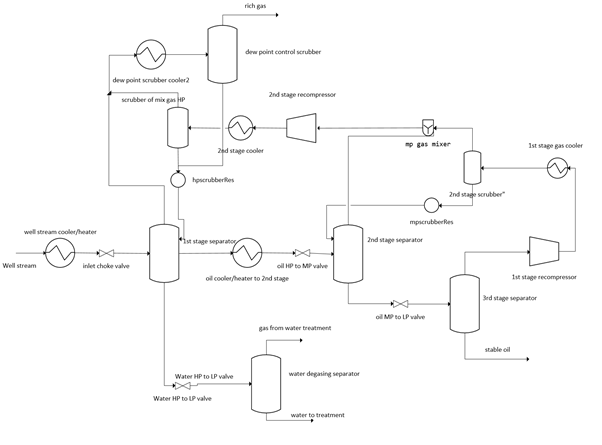

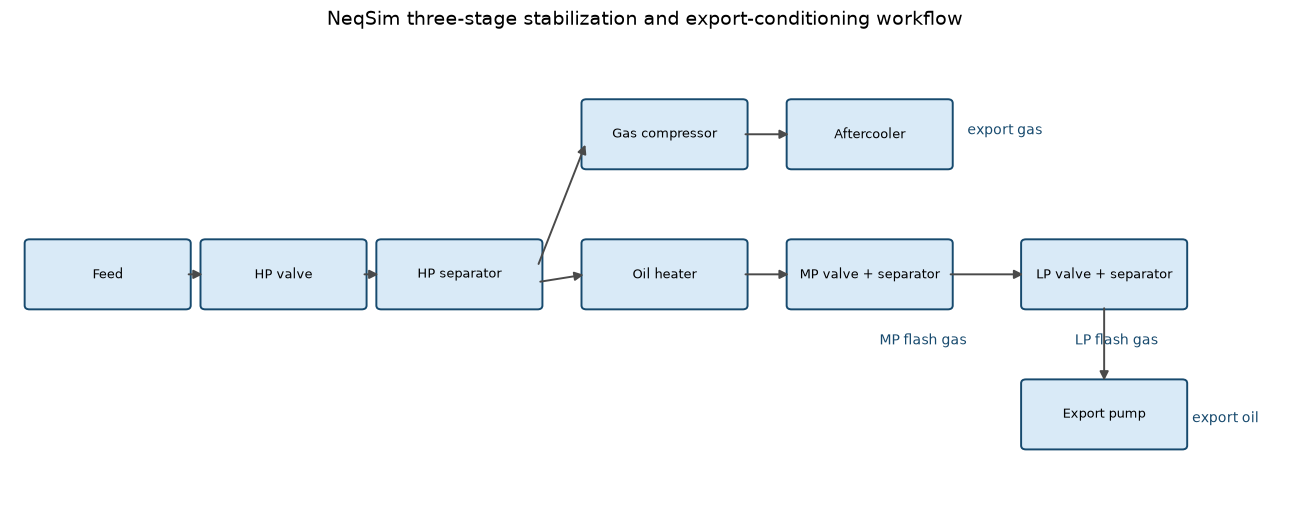

In [5]:
figure, axis = plt.subplots(figsize=(13, 5.2))
axis.set_xlim(0.0, 13.0)
axis.set_ylim(0.0, 6.0)
axis.axis("off")

equipment_boxes = {
    "Feed": (0.2, 2.5),
    "HP valve": (2.0, 2.5),
    "HP separator": (3.8, 2.5),
    "Gas compressor": (5.9, 4.3),
    "Aftercooler": (8.0, 4.3),
    "Oil heater": (5.9, 2.5),
    "MP valve + separator": (8.0, 2.5),
    "LP valve + separator": (10.4, 2.5),
    "Export pump": (10.4, 0.7),
}

for equipment_name, (x_position, y_position) in equipment_boxes.items():
    box = FancyBboxPatch(
        (x_position, y_position),
        1.6,
        0.8,
        boxstyle="round,pad=0.05",
        facecolor="#D9EAF7",
        edgecolor="#174A6E",
        linewidth=1.4,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 0.8,
        y_position + 0.4,
        equipment_name,
        ha="center",
        va="center",
        fontsize=9,
    )

connections = [
    ((1.8, 2.9), (2.0, 2.9)),
    ((3.6, 2.9), (3.8, 2.9)),
    ((5.4, 3.0), (5.9, 4.6)),
    ((7.5, 4.7), (8.0, 4.7)),
    ((5.4, 2.8), (5.9, 2.9)),
    ((7.5, 2.9), (8.0, 2.9)),
    ((9.6, 2.9), (10.4, 2.9)),
    ((11.2, 2.5), (11.2, 1.5)),
]

for start_point, end_point in connections:
    arrow = FancyArrowPatch(
        start_point,
        end_point,
        arrowstyle="-|>",
        mutation_scale=13,
        color="#4A4A4A",
        linewidth=1.4,
    )
    axis.add_patch(arrow)

axis.text(9.8, 4.7, "export gas", color="#174A6E")
axis.text(8.9, 2.0, "MP flash gas", color="#174A6E")
axis.text(10.9, 2.0, "LP flash gas", color="#174A6E")
axis.text(12.1, 1.0, "export oil", color="#174A6E")
axis.set_title(
    "NeqSim three-stage stabilization and export-conditioning workflow",
    fontsize=14,
)
figure.tight_layout()
plt.show()

The upper branch preserves the valuable pressure of the HP gas by using a compressor only for the
remaining export-pressure lift. The lower branch intentionally includes two throttling valves:
they are common, robust pressure-control devices, but their irreversibility is expected to dominate
the physical-exergy loss. The sensitivity study later quantifies this trade-off.

## 4. Physical-exergy helper

NeqSim calculates equilibrium enthalpy and entropy for the actual and reference states. Cloning is
essential: the reference flash must not mutate the live process stream. `initProperties()` is called
only before the relevant property reads, consistent with NeqSim's lazy property-initialization
strategy.

In [6]:
def physical_exergy_j_kg(fluid_state):
    actual_state = fluid_state.clone()
    actual_state.initProperties()

    reference_state = fluid_state.clone()
    reference_state.setTemperature(DEAD_STATE_TEMPERATURE_K, "K")
    reference_state.setPressure(DEAD_STATE_PRESSURE_BARA, "bara")
    TPflash(reference_state)
    reference_state.initProperties()

    enthalpy_difference_j_kg = (
        actual_state.getEnthalpy("J/kg")
        - reference_state.getEnthalpy("J/kg")
    )
    entropy_difference_j_kg_k = (
        actual_state.getEntropy("J/kgK")
        - reference_state.getEntropy("J/kgK")
    )
    return (
        enthalpy_difference_j_kg
        - DEAD_STATE_TEMPERATURE_K * entropy_difference_j_kg_k
    )


def stream_exergy_rate_kw(stream_object):
    mass_flow_kg_s = stream_object.getFlowRate("kg/sec")
    specific_exergy_j_kg = physical_exergy_j_kg(stream_object.getFluid())
    return mass_flow_kg_s * specific_exergy_j_kg / 1_000.0


dead_state_probe = feed_fluid_audit.clone()
dead_state_probe.setTemperature(DEAD_STATE_TEMPERATURE_K, "K")
dead_state_probe.setPressure(DEAD_STATE_PRESSURE_BARA, "bara")
TPflash(dead_state_probe)
dead_state_probe.initProperties()

dead_state_exergy_j_kg = physical_exergy_j_kg(dead_state_probe)
feed_specific_exergy_j_kg = physical_exergy_j_kg(feed_fluid_audit)

print(f"Feed physical exergy: {feed_specific_exergy_j_kg / 1_000.0:.6f} kJ/kg")
print(f"Dead-state physical exergy: {dead_state_exergy_j_kg:.3e} J/kg")

Feed physical exergy: 79.847343 kJ/kg
Dead-state physical exergy: 0.000e+00 J/kg


The dead-state test should return numerical zero. This is a useful limiting case: a reference-state
stream has no capacity to produce work solely because of its temperature or pressure. Positive feed
physical exergy is expected because the wellstream is hotter and much more pressurized than the
environment.

## 5. Build and run the NeqSim process

The function below accepts MP pressure as an argument so the same flowsheet can support both the
base case and independent scenarios. Every scenario clears the global process registry, rebuilds
the fluid and equipment, and executes from a clean flowsheet state.

In [7]:
def build_process_case(mp_pressure_bara=15.0):
    clearProcess()

    feed = stream("reservoir-fluid feed", build_feed_fluid())
    feed.setFlowRate(
        design_basis["feed standard flow [MSm³/day]"],
        "MSm3/day",
    )
    feed.setTemperature(design_basis["feed temperature [°C]"], "C")
    feed.setPressure(design_basis["feed pressure [bara]"], "bara")

    inlet_conditioner = heater("well stream cooler/heater", feed)
    inlet_conditioner.setOutTemperature(
        design_basis["inlet-conditioner temperature [°C]"],
        "C",
    )
    inlet_conditioner.setOutPressure(
        design_basis["inlet-conditioner pressure [bara]"],
        "bara",
    )

    hp_valve = valve("HP inlet valve", inlet_conditioner.getOutStream())
    hp_valve.setOutletPressure(
        design_basis["HP separator pressure [bara]"],
        "bara",
    )

    hp_separator = separator("HP separator", hp_valve.getOutStream())

    gas_compressor = compressor(
        "HP gas export compressor",
        hp_separator.getGasOutStream(),
        design_basis["gas export pressure [bara]"],
    )
    gas_compressor.setIsentropicEfficiency(
        design_basis["compressor isentropic efficiency [-]"],
    )

    gas_aftercooler = cooler(
        "export-gas aftercooler",
        gas_compressor.getOutStream(),
    )
    gas_aftercooler.setOutTemperature(
        design_basis["gas export temperature [°C]"],
        "C",
    )

    oil_heater = heater(
        "oil heater",
        hp_separator.getLiquidOutStream(),
    )
    oil_heater.setOutTemperature(
        design_basis["heater outlet temperature [°C]"],
        "C",
    )

    mp_valve = valve("MP letdown valve", oil_heater.getOutStream())
    mp_valve.setOutletPressure(mp_pressure_bara, "bara")
    mp_separator = separator("MP separator", mp_valve.getOutStream())

    lp_valve = valve(
        "LP letdown valve",
        mp_separator.getLiquidOutStream(),
    )
    lp_valve.setOutletPressure(
        design_basis["LP separator pressure [bara]"],
        "bara",
    )
    lp_separator = separator("LP separator", lp_valve.getOutStream())

    export_pump = pump(
        "stabilized-oil export pump",
        lp_separator.getLiquidOutStream(),
    )
    export_pump.setOutletPressure(
        design_basis["oil export pressure [bara]"],
        "bara",
    )
    export_pump.setIsentropicEfficiency(
        design_basis["pump isentropic efficiency [-]"],
    )

    runProcess()

    return {
        "feed": feed,
        "well stream cooler/heater": inlet_conditioner,
        "HP inlet valve": hp_valve,
        "HP separator": hp_separator,
        "HP gas export compressor": gas_compressor,
        "export-gas aftercooler": gas_aftercooler,
        "oil heater": oil_heater,
        "MP letdown valve": mp_valve,
        "MP separator": mp_separator,
        "LP letdown valve": lp_valve,
        "LP separator": lp_separator,
        "stabilized-oil export pump": export_pump,
        "process": getProcess(),
    }

In [8]:
# Preserve the legacy process-import workflow with a self-contained model.
base_case = build_process_case()
GasOilProcess = base_case["process"]

hp_gas = base_case["HP separator"].getGasOutStream()
export_gas = base_case["export-gas aftercooler"].getOutStream()
mp_gas = base_case["MP separator"].getGasOutStream()
lp_gas = base_case["LP separator"].getGasOutStream()
stable_oil = base_case["LP separator"].getLiquidOutStream()
export_oil = base_case["stabilized-oil export pump"].getOutStream()

print("Self-contained replacement for offshorePro.neqsim converged.")
print(f"Export-gas flow: {export_gas.getFlowRate('kg/hr'):.6f} kg/h")
print(f"Stable-oil flow: {stable_oil.getFlowRate('kg/hr'):.6f} kg/h")
print(f"Export-oil pressure: {export_oil.getPressure('bara'):.6f} bara")

Self-contained replacement for offshorePro.neqsim converged.
Export-gas flow: 142444.627578 kg/h
Stable-oil flow: 1302922.697951 kg/h
Export-oil pressure: 20.000000 bara


In [9]:
import time

start_time = time.perf_counter()
GasOilProcess.run()
elapsed_seconds = time.perf_counter() - start_time

print(f"Repeat simulation run: {elapsed_seconds:.4f} s")

Repeat simulation run: 0.0024 s


The process is fully connected: a unit's outlet stream is passed directly to the next unit. NeqSim
therefore propagates pressure, temperature, composition, phase state, and flow without hidden
spreadsheet transfers. Positive HP gas and stabilized-oil flows confirm that the selected feed
conditions produce the intended two-product process.

## 6. Inspect stream states and physical exergy

Before comparing irreversibilities, inspect the state variables that drive them. Density is
initialized immediately before reading it. Phase count is included because an unexpected phase can
invalidate an assumed equipment model or a downstream hydraulic calculation.

In [10]:
def stream_state(name, stream_object):
    stream_fluid = stream_object.getFluid()
    stream_fluid.initPhysicalProperties()
    return {
        "Stream": name,
        "Mass flow [kg/h]": stream_object.getFlowRate("kg/hr"),
        "Temperature [°C]": stream_object.getTemperature("C"),
        "Pressure [bara]": stream_object.getPressure("bara"),
        "Density [kg/m³]": stream_fluid.getDensity("kg/m3"),
        "Phases [-]": stream_fluid.getNumberOfPhases(),
        "Physical exergy [kW]": stream_exergy_rate_kw(stream_object),
    }


named_streams = {
    "Feed": base_case["feed"],
    "After HP valve": base_case["HP inlet valve"].getOutStream(),
    "HP gas": hp_gas,
    "Export gas": export_gas,
    "Heated HP oil": base_case["oil heater"].getOutStream(),
    "MP flash gas": mp_gas,
    "LP flash gas": lp_gas,
    "Stable oil": stable_oil,
    "Export oil": export_oil,
}

state_table = pd.DataFrame(
    [
        stream_state(stream_name, stream_object)
        for stream_name, stream_object in named_streams.items()
    ]
)
display(state_table.round(6))

,Stream,Mass flow [kg/h],Temperature [°C],Pressure [bara],Density [kg/m³],Phases [-],Physical exergy [kW]
0,Feed,1.641585e+06,65.000000,120.00,613.945962,2,36410.048162
1,After HP valve,1.641585e+06,65.886763,51.21,296.751163,2,31266.426273
2,HP gas,1.424446e+05,65.886763,51.21,42.657212,1,17140.070518
3,Export gas,1.424446e+05,33.000000,160.00,183.721589,1,20322.372999
4,Heated HP oil,1.499140e+06,85.000000,51.21,617.957249,2,16698.419591
5,MP flash gas,9.259637e+04,79.973055,15.00,14.783318,1,6181.803743
6,LP flash gas,1.036210e+05,69.618401,1.80,3.052518,1,1136.649652
7,Stable oil,1.302923e+06,69.618401,1.80,747.648529,1,3485.954777
8,Export oil,1.302923e+06,70.370884,20.00,749.613862,1,4471.867216


The pressure profile should follow the equipment specification exactly. Physical-exergy rates are
not additive across the separator because each composition uses its own composition-preserving
reference state. They remain valuable state indicators and provide valid one-in/one-out balances
around the non-separating equipment audited below.

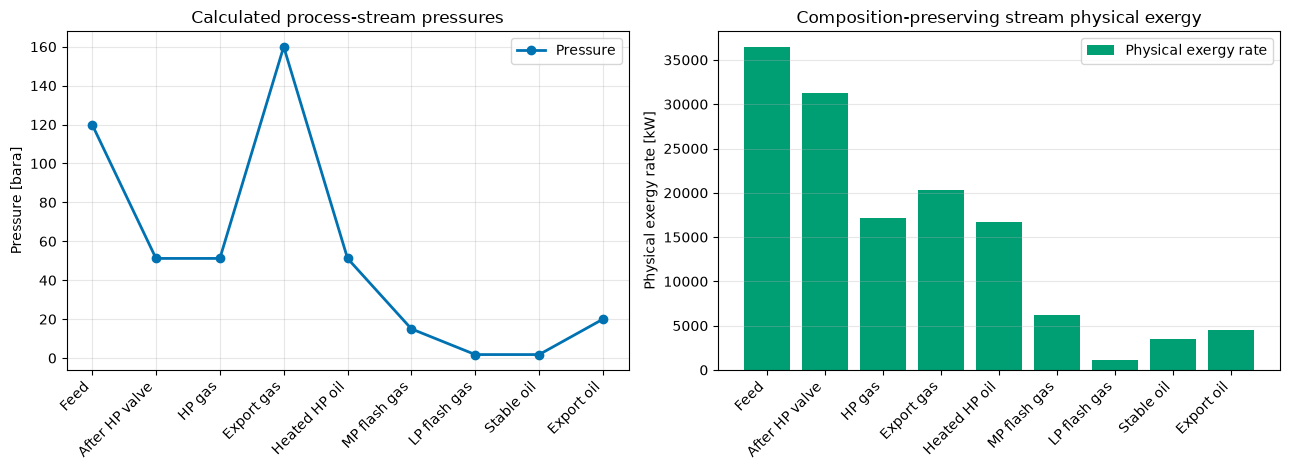

In [11]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
stream_positions = np.arange(len(state_table))

axes[0].plot(
    stream_positions,
    state_table["Pressure [bara]"],
    marker="o",
    color="#0072B2",
    linewidth=2.0,
    label="Pressure",
)
axes[0].set_xticks(
    stream_positions,
    state_table["Stream"],
    rotation=45,
    ha="right",
)
axes[0].set_ylabel("Pressure [bara]")
axes[0].set_title("Calculated process-stream pressures")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].bar(
    stream_positions,
    state_table["Physical exergy [kW]"],
    color="#009E73",
    label="Physical exergy rate",
)
axes[1].set_xticks(
    stream_positions,
    state_table["Stream"],
    rotation=45,
    ha="right",
)
axes[1].set_ylabel("Physical exergy rate [kW]")
axes[1].set_title("Composition-preserving stream physical exergy")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

figure.tight_layout()
plt.show()

The left plot reveals every imposed pressure lift and pressure loss. The right plot shows where
temperature and pressure give streams the greatest work potential. The gas and liquid product bars
must not be summed as a full plant exergy balance because their chemical compositions differ.

## 7. First-law validation: mass, components, and energy

Second-law conclusions are meaningful only after the flowsheet closes its first-law balances.
Products are export gas, MP and LP flash gases, and stable oil. Export oil is not added separately
because pumping does not create another material product. The final audit accepts at most 1 W of
absolute numerical closure error, which is conservative relative to the multi-megawatt duties and
avoids treating sub-watt flash-solver roundoff as a physical imbalance.

In [12]:
def component_molar_rates(stream_object):
    stream_fluid = stream_object.getFluid()
    total_molar_rate = stream_object.getFlowRate("mole/sec")
    return {
        stream_fluid.getComponent(index).getComponentName(): (
            total_molar_rate * stream_fluid.getComponent(index).getz()
        )
        for index in range(stream_fluid.getNumberOfComponents())
    }


product_streams = [export_gas, mp_gas, lp_gas, stable_oil]
feed_mass_kg_h = base_case["feed"].getFlowRate("kg/hr")
product_mass_kg_h = sum(
    product_stream.getFlowRate("kg/hr")
    for product_stream in product_streams
)
mass_residual_kg_h = feed_mass_kg_h - product_mass_kg_h

feed_component_rates = component_molar_rates(base_case["feed"])
product_component_rates = [
    component_molar_rates(product_stream)
    for product_stream in product_streams
]
component_residuals = {}

for component_name, feed_rate in feed_component_rates.items():
    outlet_rate = sum(
        rates.get(component_name, 0.0)
        for rates in product_component_rates
    )
    component_residuals[component_name] = feed_rate - outlet_rate

maximum_component_residual_mol_s = max(
    abs(residual)
    for residual in component_residuals.values()
)
normalized_mass_residual = abs(mass_residual_kg_h) / feed_mass_kg_h

print(f"Mass residual: {mass_residual_kg_h:.3e} kg/h")
print(f"Normalized mass residual: {normalized_mass_residual:.3e} [-]")
print(
    "Maximum component residual: "
    f"{maximum_component_residual_mol_s:.3e} mol/s"
)

Mass residual: 1.009e-05 kg/h
Normalized mass residual: 6.146e-12 [-]
Maximum component residual: 5.915e-09 mol/s


In [13]:
def enthalpy_rate_w(stream_object):
    return stream_object.getFluid().getEnthalpy()


energy_rows = []

one_in_one_out_units = [
    (
        "well stream cooler/heater",
        base_case["feed"],
        base_case["well stream cooler/heater"].getOutStream(),
        base_case["well stream cooler/heater"].getDuty(),
    ),
    (
        "HP inlet valve",
        base_case["well stream cooler/heater"].getOutStream(),
        base_case["HP inlet valve"].getOutStream(),
        0.0,
    ),
    (
        "oil heater",
        base_case["HP separator"].getLiquidOutStream(),
        base_case["oil heater"].getOutStream(),
        base_case["oil heater"].getDuty(),
    ),
    (
        "MP letdown valve",
        base_case["oil heater"].getOutStream(),
        base_case["MP letdown valve"].getOutStream(),
        0.0,
    ),
    (
        "LP letdown valve",
        base_case["MP separator"].getLiquidOutStream(),
        base_case["LP letdown valve"].getOutStream(),
        0.0,
    ),
    (
        "stabilized-oil export pump",
        stable_oil,
        export_oil,
        base_case["stabilized-oil export pump"].getPower("W"),
    ),
    (
        "HP gas export compressor",
        hp_gas,
        base_case["HP gas export compressor"].getOutStream(),
        base_case["HP gas export compressor"].getPower("W"),
    ),
    (
        "export-gas aftercooler",
        base_case["HP gas export compressor"].getOutStream(),
        export_gas,
        base_case["export-gas aftercooler"].getDuty(),
    ),
]

for unit_name, inlet_stream, outlet_stream, energy_input_w in one_in_one_out_units:
    residual_w = enthalpy_rate_w(inlet_stream) + energy_input_w
    residual_w -= enthalpy_rate_w(outlet_stream)
    energy_rows.append(
        {
            "Unit": unit_name,
            "Energy input [kW]": energy_input_w / 1_000.0,
            "Energy residual [W]": residual_w,
        }
    )

energy_table = pd.DataFrame(energy_rows)
maximum_energy_residual_w = energy_table["Energy residual [W]"].abs().max()
display(energy_table.round(9))

,Unit,Energy input [kW],Energy residual [W]
0,well stream cooler/heater,5746.242035,0.000000e+00
1,HP inlet valve,0.000000,-1.023324e-02
2,oil heater,18525.079578,0.000000e+00
3,MP letdown valve,0.000000,-2.707303e-03
4,LP letdown valve,0.000000,-2.736361e-02
5,stabilized-oil export pump,1247.715546,0.000000e+00
6,HP gas export compressor,8110.091589,0.000000e+00
7,export-gas aftercooler,-16451.903583,1.000000e-09


Valves should be isenthalpic, while heater, cooler, pump, and compressor enthalpy changes should
match their signed duty or shaft input. NeqSim reports cooler duty as negative because heat leaves
the process. Small floating-point residuals are expected; large residuals would stop publication.

## 8. Equipment exergy destruction

For each composition-preserving unit, the direct exergy balance is compared with the
Gouy–Stodola relation

$$

\dot E_D = T_0\dot S_{gen}.

$$

For an adiabatic valve, $\dot S_{gen}=\dot m(s_{out}-s_{in})$. For a heater or cooler with signed
heat input $\dot Q$, $\dot S_{gen}=\dot m(s_{out}-s_{in})-\dot Q/T_b$. Agreement between the two
independent forms is a focused validation of signs, units, and boundary temperatures.

### Native NeqSim entropy-production audit

The original notebook called the process-level and unit-level NeqSim entropy production APIs. That workflow is retained below, now with a structured table and explicit SI units. The direct stream exergy balances later provide an independent validation for composition-preserving equipment. NeqSim 3.16.0 has a separator-specific defect in this legacy method: it incorrectly sends the entropy unit to a flow-rate converter. The cell therefore calls the native API where operational and uses the same inlet/outlet entropy balance for affected separators. The focused upstream repair is tracked in [NeqSim PR #2626](https://github.com/equinor/neqsim/pull/2626).

In [14]:
reference_temperature_k = 298.15

def stream_entropy_rate_j_k(stream):
    fluid = stream.getFluid()
    fluid.init(3)
    return fluid.getEntropy()

def robust_unit_entropy_production(unit_operation):
    try:
        native_value = unit_operation.getEntropyProduction("J/K")
    except Exception:
        inlet_entropy = sum(
            stream_entropy_rate_j_k(stream)
            for stream in unit_operation.getInletStreams()
        )
        outlet_entropy = sum(
            stream_entropy_rate_j_k(stream)
            for stream in unit_operation.getOutletStreams()
        )
        return outlet_entropy - inlet_entropy, "stream-balance fallback"
    return native_value, "native API"

native_entropy_rows = []

for unit_operation in GasOilProcess.getUnitOperations():
    entropy_production_j_k, calculation_path = (
        robust_unit_entropy_production(unit_operation)
    )
    native_entropy_rows.append(
        {
            "Unit": unit_operation.getName(),
            "Entropy production [J/(s K)]": entropy_production_j_k,
            "Lost work at 298.15 K [MW]": (
                reference_temperature_k
                * entropy_production_j_k
                / 1.0e6
            ),
            "Calculation path": calculation_path,
        }
    )

native_entropy_table = pd.DataFrame(native_entropy_rows)
total_entropy_production_j_k = native_entropy_table[
    "Entropy production [J/(s K)]"
].sum()
total_lost_work_mw = (
    reference_temperature_k
    * total_entropy_production_j_k
    / 1.0e6
)
total_cooling_duty_mw = GasOilProcess.getCoolerDuty("J/sec") / 1.0e6
total_heater_duty_mw = GasOilProcess.getHeaterDuty("J/sec") / 1.0e6
total_power_mw = GasOilProcess.getPower("W") / 1.0e6

try:
    process_entropy_api_value = GasOilProcess.getEntropyProduction("J/K")
except Exception:
    process_entropy_api_status = (
        "NeqSim 3.16.0 separator unit-conversion defect reproduced; "
        "using explicit unit balances."
    )
else:
    process_entropy_api_status = (
        f"Native process total: {process_entropy_api_value:.6f} J/(s K)"
    )

display(native_entropy_table.round(6))
print(process_entropy_api_status)
print(
    f"Robust total entropy production: "
    f"{total_entropy_production_j_k:.6f} J/(s K)"
)
print(f"Total lost work at 298.15 K: {total_lost_work_mw:.6f} MW")
print(f"Signed cooler duty: {total_cooling_duty_mw:.6f} MW")
print(f"Signed heater duty: {total_heater_duty_mw:.6f} MW")
print(f"Total shaft power: {total_power_mw:.6f} MW")

NeqSim 3.16.0 separator unit-conversion defect reproduced; using explicit unit balances.
Robust total entropy production: 70748.819045 J/(s K)
Total lost work at 298.15 K: 21.093760 MW
Signed cooler duty: -16.451904 MW
Signed heater duty: 7.819418 MW
Total shaft power: 9.357807 MW


,Unit,Entropy production [J/(s K)],Lost work at 298.15 K [MW],Calculation path
0,"(r, e, s, e, r, v, o, i, r, -, f, l, u, i, d, ...",0.000000,0.000000,native API
1,"(w, e, l, l, , s, t, r, e, a, m, , c, o, o, ...",37339.502019,11.132773,native API
2,"(H, P, , i, n, l, e, t, , v, a, l, v, e)",452.842016,0.135015,native API
3,"(H, P, , s, e, p, a, r, a, t, o, r)",0.000000,0.000000,stream-balance fallback
4,"(H, P, , g, a, s, , e, x, p, o, r, t, , c, ...",4669.957032,1.392348,native API
5,"(e, x, p, o, r, t, -, g, a, s, , a, f, t, e, ...",-44663.413476,-13.316397,native API
6,"(o, i, l, , h, e, a, t, e, r)",53147.127322,15.845816,native API
7,"(M, P, , l, e, t, d, o, w, n, , v, a, l, v, e)",11698.959111,3.488045,native API
8,"(M, P, , s, e, p, a, r, a, t, o, r)",0.000000,0.000000,stream-balance fallback
9,"(L, P, , l, e, t, d, o, w, n, , v, a, l, v, e)",7195.279662,2.145273,native API


In [15]:
def equipment_exergy_row(
    unit_name,
    inlet_stream,
    outlet_stream,
    work_input_kw=0.0,
    heat_input_kw=0.0,
    boundary_temperature_k=None,
):
    heat_exergy_kw = 0.0

    if boundary_temperature_k is not None:
        heat_exergy_kw = (
            1.0 - DEAD_STATE_TEMPERATURE_K / boundary_temperature_k
        ) * heat_input_kw

    inlet_exergy_kw = stream_exergy_rate_kw(inlet_stream)
    outlet_exergy_kw = stream_exergy_rate_kw(outlet_stream)
    destruction_kw = (
        inlet_exergy_kw
        + work_input_kw
        + heat_exergy_kw
        - outlet_exergy_kw
    )

    mass_flow_kg_s = inlet_stream.getFlowRate("kg/sec")
    inlet_entropy_j_kg_k = inlet_stream.getFluid().getEntropy("J/kgK")
    outlet_entropy_j_kg_k = outlet_stream.getFluid().getEntropy("J/kgK")
    entropy_generation_kw_k = (
        mass_flow_kg_s
        * (outlet_entropy_j_kg_k - inlet_entropy_j_kg_k)
        / 1_000.0
    )

    if boundary_temperature_k is not None:
        entropy_generation_kw_k -= heat_input_kw / boundary_temperature_k

    gouy_stodola_kw = DEAD_STATE_TEMPERATURE_K * entropy_generation_kw_k

    return {
        "Unit": unit_name,
        "Work input [kW]": work_input_kw,
        "Heat input [kW]": heat_input_kw,
        "Exergy destroyed [kW]": destruction_kw,
        "Gouy-Stodola [kW]": gouy_stodola_kw,
        "Closure residual [kW]": destruction_kw - gouy_stodola_kw,
    }

In [16]:
exergy_rows = [
    equipment_exergy_row(
        "Wellstream conditioner",
        base_case["feed"],
        base_case["well stream cooler/heater"].getOutStream(),
        heat_input_kw=(
            base_case["well stream cooler/heater"].getDuty() / 1_000.0
        ),
        boundary_temperature_k=HEAT_SOURCE_TEMPERATURE_K,
    ),
    equipment_exergy_row(
        "HP inlet valve",
        base_case["well stream cooler/heater"].getOutStream(),
        base_case["HP inlet valve"].getOutStream(),
    ),
    equipment_exergy_row(
        "Oil heater",
        base_case["HP separator"].getLiquidOutStream(),
        base_case["oil heater"].getOutStream(),
        heat_input_kw=base_case["oil heater"].getDuty() / 1_000.0,
        boundary_temperature_k=HEAT_SOURCE_TEMPERATURE_K,
    ),
    equipment_exergy_row(
        "MP letdown valve",
        base_case["oil heater"].getOutStream(),
        base_case["MP letdown valve"].getOutStream(),
    ),
    equipment_exergy_row(
        "LP letdown valve",
        base_case["MP separator"].getLiquidOutStream(),
        base_case["LP letdown valve"].getOutStream(),
    ),
    equipment_exergy_row(
        "Oil export pump",
        stable_oil,
        export_oil,
        work_input_kw=(
            base_case["stabilized-oil export pump"].getPower("kW")
        ),
    ),
    equipment_exergy_row(
        "HP gas compressor",
        hp_gas,
        base_case["HP gas export compressor"].getOutStream(),
        work_input_kw=(
            base_case["HP gas export compressor"].getPower("kW")
        ),
    ),
    equipment_exergy_row(
        "Gas aftercooler",
        base_case["HP gas export compressor"].getOutStream(),
        export_gas,
        heat_input_kw=(
            base_case["export-gas aftercooler"].getDuty() / 1_000.0
        ),
        boundary_temperature_k=COOLING_BOUNDARY_TEMPERATURE_K,
    ),
]

exergy_table = pd.DataFrame(exergy_rows)
total_audited_destruction_kw = exergy_table["Exergy destroyed [kW]"].sum()
maximum_exergy_closure_kw = exergy_table["Closure residual [kW]"].abs().max()
exergy_intensity_kj_kg = (
    total_audited_destruction_kw
    / (feed_mass_kg_h / 3_600.0)
)

display(exergy_table.round(6))
print(f"Audited exergy destruction: {total_audited_destruction_kw:.6f} kW")
print(f"Audited exergy intensity: {exergy_intensity_kj_kg:.6f} kJ/kg feed")

Audited exergy destruction: 19759.520344 kW
Audited exergy intensity: 43.332686 kJ/kg feed


,Unit,Work input [kW],Heat input [kW],Exergy destroyed [kW],Gouy-Stodola [kW],Closure residual [kW]
0,Wellstream conditioner,0.000000,5746.242035,6908.727175,6908.727175,0.000000
1,HP inlet valve,0.000000,0.000000,130.486417,130.486427,-0.000010
2,Oil heater,0.000000,18525.079578,2900.387342,2900.387342,0.000000
3,MP letdown valve,0.000000,0.000000,3371.055065,3371.055068,-0.000003
4,LP letdown valve,0.000000,0.000000,2073.319807,2073.319835,-0.000027
5,Oil export pump,1247.715546,0.000000,261.803108,261.803108,-0.000000
6,HP gas compressor,8110.091589,0.000000,1345.648119,1345.648119,-0.000000
7,Gas aftercooler,0.000000,-16451.903583,2768.093311,2768.093311,0.000000


The closure residual compares a stream exergy balance with an entropy-generation calculation.
Agreement confirms the two methods use consistent signs and units. The total covers only the seven
composition-preserving units; separators are intentionally excluded. The intensity in kJ/kg feed
is useful for comparing alternatives with the same feed definition.

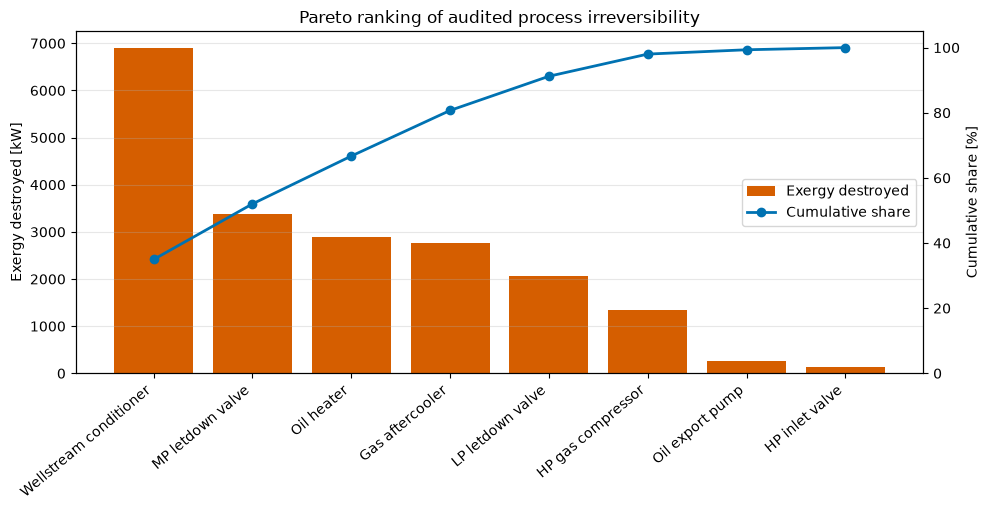

In [17]:
ranked_exergy = exergy_table.sort_values(
    "Exergy destroyed [kW]",
    ascending=False,
).reset_index(drop=True)
ranked_exergy["Cumulative share [%]"] = (
    100.0
    * ranked_exergy["Exergy destroyed [kW]"].cumsum()
    / total_audited_destruction_kw
)

figure, primary_axis = plt.subplots(figsize=(10, 5.2))
bar_positions = np.arange(len(ranked_exergy))

primary_axis.bar(
    bar_positions,
    ranked_exergy["Exergy destroyed [kW]"],
    color="#D55E00",
    label="Exergy destroyed",
)
primary_axis.set_xticks(
    bar_positions,
    ranked_exergy["Unit"],
    rotation=40,
    ha="right",
)
primary_axis.set_ylabel("Exergy destroyed [kW]")
primary_axis.set_title("Pareto ranking of audited process irreversibility")
primary_axis.grid(axis="y", alpha=0.3)

secondary_axis = primary_axis.twinx()
secondary_axis.plot(
    bar_positions,
    ranked_exergy["Cumulative share [%]"],
    color="#0072B2",
    marker="o",
    linewidth=2.0,
    label="Cumulative share",
)
secondary_axis.set_ylabel("Cumulative share [%]")
secondary_axis.set_ylim(0.0, 105.0)

handles_1, labels_1 = primary_axis.get_legend_handles_labels()
handles_2, labels_2 = secondary_axis.get_legend_handles_labels()
primary_axis.legend(
    handles_1 + handles_2,
    labels_1 + labels_2,
    loc="center right",
)

figure.tight_layout()
plt.show()

The Pareto plot converts a long equipment table into an engineering decision aid. The tallest bars
identify where pressure recovery, pressure-level changes, better efficiency, or closer utility
temperatures could have the largest second-law benefit. A large valve loss does not automatically
justify an expander: liquid handling, control range, reliability, and economics still matter.

## 9. Separator-pressure sensitivity

MP pressure changes how much gas flashes in the intermediate stage and how the remaining pressure
drop is divided between the MP and LP valves. The final application rebuilds and solves five
independent NeqSim flowsheets, retrieves oil recovery and true vapour pressure (TVP), and repeats the
composition-preserving valve audit.

In [18]:
def true_vapour_pressure_bara(stream_object, temperature_c=37.8):
    pressure_probe = stream_object.clone()
    return pressure_probe.TVP(temperature_c, "C")


def run_pressure_scenario(mp_pressure_bara):
    scenario = build_process_case(mp_pressure_bara=mp_pressure_bara)
    scenario_feed = scenario["feed"]
    scenario_stable_oil = scenario["LP separator"].getLiquidOutStream()

    hp_valve_row = equipment_exergy_row(
        "HP inlet valve",
        scenario["well stream cooler/heater"].getOutStream(),
        scenario["HP inlet valve"].getOutStream(),
    )
    mp_valve_row = equipment_exergy_row(
        "MP letdown valve",
        scenario["oil heater"].getOutStream(),
        scenario["MP letdown valve"].getOutStream(),
    )
    lp_valve_row = equipment_exergy_row(
        "LP letdown valve",
        scenario["MP separator"].getLiquidOutStream(),
        scenario["LP letdown valve"].getOutStream(),
    )
    valve_destruction_kw = sum(
        row["Exergy destroyed [kW]"]
        for row in [hp_valve_row, mp_valve_row, lp_valve_row]
    )

    return {
        "MP pressure [bara]": mp_pressure_bara,
        "Stable-oil flow [kg/h]": scenario_stable_oil.getFlowRate("kg/hr"),
        "Oil recovery [% feed]": (
            100.0
            * scenario_stable_oil.getFlowRate("kg/hr")
            / scenario_feed.getFlowRate("kg/hr")
        ),
        "TVP at 37.8 °C [bara]": true_vapour_pressure_bara(
            scenario_stable_oil,
        ),
        "Valve exergy destruction [kW]": valve_destruction_kw,
    }


mp_pressures_bara = [8.0, 11.0, 15.0, 18.0, 22.0]
scenario_table = pd.DataFrame(
    [
        run_pressure_scenario(mp_pressure_bara)
        for mp_pressure_bara in mp_pressures_bara
    ]
)
display(scenario_table.round(6))

,MP pressure [bara],Stable-oil flow [kg/h],Oil recovery [% feed],TVP at 37.8 °C [bara],Valve exergy destruction [kW]
0,8.0,1.311039e+06,79.864204,1.003462,6140.069750
1,11.0,1.308302e+06,79.697493,1.017061,5708.472961
2,15.0,1.302923e+06,79.369814,1.041937,5574.861303
3,18.0,1.298786e+06,79.117814,1.060886,5654.833777
4,22.0,1.293543e+06,78.798423,1.084922,5904.841039


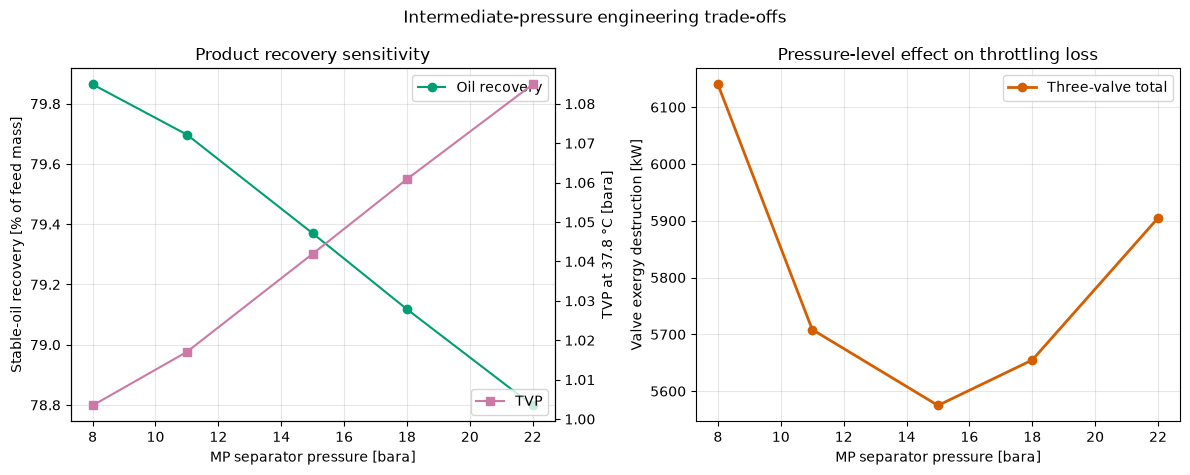

In [19]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(
    scenario_table["MP pressure [bara]"],
    scenario_table["Oil recovery [% feed]"],
    color="#009E73",
    marker="o",
    label="Oil recovery",
)
axes[0].set_xlabel("MP separator pressure [bara]")
axes[0].set_ylabel("Stable-oil recovery [% of feed mass]")
axes[0].set_title("Product recovery sensitivity")
axes[0].grid(alpha=0.3)
axes[0].legend()

quality_axis = axes[0].twinx()
quality_axis.plot(
    scenario_table["MP pressure [bara]"],
    scenario_table["TVP at 37.8 °C [bara]"],
    color="#CC79A7",
    marker="s",
    label="TVP",
)
quality_axis.set_ylabel("TVP at 37.8 °C [bara]")
quality_axis.legend(loc="lower right")

axes[1].plot(
    scenario_table["MP pressure [bara]"],
    scenario_table["Valve exergy destruction [kW]"],
    color="#D55E00",
    marker="o",
    linewidth=2.0,
    label="Three-valve total",
)
axes[1].set_xlabel("MP separator pressure [bara]")
axes[1].set_ylabel("Valve exergy destruction [kW]")
axes[1].set_title("Pressure-level effect on throttling loss")
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.suptitle("Intermediate-pressure engineering trade-offs")
figure.tight_layout()
plt.show()

The sensitivity plot must be read as a trade-off, not an optimizer. Oil recovery and TVP describe
product quantity and volatility; valve exergy destruction describes only the audited
pressure-conditioning loss. Mechanical design, separator capacity, gas compression, operating
envelope, and product specifications must be added before choosing a pressure.

## 10. Reusable engineering snapshot

The final function returns plain Python values for dashboards, automated studies, or regression
tests. It demonstrates the reusable workflow: configure a case, run NeqSim, retrieve results,
calculate second-law indicators, and expose validation information without relying on notebook
display state.

In [20]:
def engineering_snapshot(mp_pressure_bara=15.0):
    case_result = run_pressure_scenario(mp_pressure_bara)
    return {
        "model": "Peng-Robinson with characterized C6-C20 fractions",
        "mp_pressure_bara": case_result["MP pressure [bara]"],
        "stable_oil_kg_h": case_result["Stable-oil flow [kg/h]"],
        "oil_tvp_37_8_c_bara": case_result["TVP at 37.8 °C [bara]"],
        "valve_exergy_destruction_kw": (
            case_result["Valve exergy destruction [kW]"]
        ),
        "dead_state_temperature_k": DEAD_STATE_TEMPERATURE_K,
        "dead_state_pressure_bara": DEAD_STATE_PRESSURE_BARA,
        "exergy_scope": "composition-preserving physical exergy",
    }


base_snapshot = engineering_snapshot()
display(pd.Series(base_snapshot, name="Base-case engineering snapshot"))

model                          Peng-Robinson with characterized C6-C20 fractions
mp_pressure_bara                                                            15.0
stable_oil_kg_h                                                   1302922.697992
oil_tvp_37_8_c_bara                                                     1.041937
valve_exergy_destruction_kw                                          5574.861292
dead_state_temperature_k                                                  288.15
dead_state_pressure_bara                                                 1.01325
exergy_scope                              composition-preserving physical exergy
Name: Base-case engineering snapshot, dtype: object

## 11. Validation and acceptance checks

The assertions below are intentionally focused. They test composition normalization, reference-state
behavior, product flows, exact specified pressures, mass/component/energy closure, positive and
finite exergy destruction, independent Gouy–Stodola closure, physically plausible oil density and
TVP, scenario convergence, and bounded trends. A failing assertion is evidence to diagnose, not a
result to hide.

In [21]:
stable_oil.getFluid().initPhysicalProperties()
stable_oil_density_kg_m3 = stable_oil.getFluid().getDensity("kg/m3")
base_oil_tvp_bara = true_vapour_pressure_bara(stable_oil)

engineering_checks = {
    "relative composition total is unchanged": math.isclose(
        composition_total,
        101.5,
        rel_tol=0.0,
        abs_tol=1.0e-12,
    ),
    "normalized composition sums to one": abs(normalized_sum - 1.0) < 1.0e-12,
    "dead-state exergy is zero": abs(dead_state_exergy_j_kg) < 1.0e-8,
    "feed physical exergy is positive": feed_specific_exergy_j_kg > 0.0,
    "export gas flow is positive": export_gas.getFlowRate("kg/hr") > 0.0,
    "stable oil flow is positive": stable_oil.getFlowRate("kg/hr") > 0.0,
    "MP flash gas flow is positive": mp_gas.getFlowRate("kg/hr") > 0.0,
    "LP flash gas flow is positive": lp_gas.getFlowRate("kg/hr") > 0.0,
    "oil export pressure is met": math.isclose(
        export_oil.getPressure("bara"),
        design_basis["oil export pressure [bara]"],
        abs_tol=1.0e-8,
    ),
    "gas export pressure is met": math.isclose(
        export_gas.getPressure("bara"),
        design_basis["gas export pressure [bara]"],
        abs_tol=1.0e-8,
    ),
    "mass balance closes": normalized_mass_residual < 1.0e-10,
    "component balance closes": maximum_component_residual_mol_s < 1.0e-8,
    "energy balances close": maximum_energy_residual_w < 1.0,
    "exergy methods agree": maximum_exergy_closure_kw < 1.0e-3,
    "all audited destructions are nonnegative": (
        exergy_table["Exergy destroyed [kW]"] >= -1.0e-8
    ).all(),
    "audited destruction is finite": np.isfinite(
        exergy_table["Exergy destroyed [kW]"]
    ).all(),
    "oil density is plausible": 600.0 < stable_oil_density_kg_m3 < 950.0,
    "oil TVP is plausible": 0.5 < base_oil_tvp_bara < 2.5,
    "all pressure scenarios converged": len(scenario_table) == 5,
    "scenario oil flows are finite": np.isfinite(
        scenario_table["Stable-oil flow [kg/h]"]
    ).all(),
    "scenario TVP values are positive": (
        scenario_table["TVP at 37.8 °C [bara]"] > 0.0
    ).all(),
    "scenario exergy values are nonnegative": (
        scenario_table["Valve exergy destruction [kW]"] >= 0.0
    ).all(),
}

failed_checks = [
    check_name
    for check_name, check_passed in engineering_checks.items()
    if not check_passed
]

print(f"Stable-oil density: {stable_oil_density_kg_m3:.6f} kg/m³")
print(f"Stable-oil TVP at 37.8 °C: {base_oil_tvp_bara:.6f} bara")
print(f"Maximum energy residual: {maximum_energy_residual_w:.3e} W")
print(f"Maximum exergy-method residual: {maximum_exergy_closure_kw:.3e} kW")

assert not failed_checks, f"Failed checks: {failed_checks}"

print(f"All {len(engineering_checks)} engineering checks passed.")

Stable-oil density: 747.648529 kg/m³
Stable-oil TVP at 37.8 °C: 1.041937 bara
Maximum energy residual: 2.736e-02 W
Maximum exergy-method residual: 2.736e-05 kW
All 22 engineering checks passed.


## Troubleshooting

- **No liquid phase:** lower feed temperature, increase heavy fractions, or verify composition units.
- **A pressure is not met:** confirm absolute pressure units (`bara`) and that every upstream unit ran.
- **Negative exergy destruction:** check signed heat duty, work direction, boundary temperature, and
  whether composition changed across the selected control volume.
- **Large energy residual:** compare NeqSim duty units with stream enthalpy-rate units; the latter are
  J/s for a flowing thermodynamic system.
- **Unexpected property values:** initialize physical properties immediately before reading density,
  viscosity, or conductivity.
- **Slow scenario study:** reduce the number of cases during development, then restore the full
  independent sweep for final validation.

## Applicability and limitations

The workflow is appropriate for conceptual screening, model QA, and locating thermodynamic
improvement opportunities. It assumes steady state, equilibrium separators, negligible kinetic and
potential energy, no pressure drop outside specified equipment, and constant heat-source and
cooling-boundary temperatures. The synthetic fluid is not tuned to laboratory data.

Do not use the physical-exergy sum as a complete plant exergy balance across separators. A design
study should add chemical exergy, common environmental composition, actual utility systems,
equipment curves, heat-exchanger temperature profiles, hydraulic pressure drops, separator sizing,
emissions, safety constraints, reliability, and economics.

## Summary

This notebook connected NeqSim thermodynamics to a complete oil-and-gas processing workflow,
verified first-law closure, and used two independent second-law calculations to rank seven
composition-preserving equipment items. The retained process diagram, stream-state comparison,
Pareto chart, and pressure sensitivity make the engineering conclusions inspectable.

The core reusable pattern is: define a dead state, calculate composition-preserving stream physical
exergy, close mass and energy balances, calculate equipment destruction, verify Gouy–Stodola
closure, and only then compare scenarios.

## Further exercises

1. Replace the synthetic composition with a public or anonymized PVT characterization.
2. Compare one valve with a hydraulic power-recovery device using an appropriate NeqSim unit.
3. Add gas recompression for the MP and LP flash gas and audit its power and exergy destruction.
4. Sweep pump and compressor isentropic efficiency and calculate avoided exergy destruction.
5. Represent heater and aftercooler temperature profiles with heat exchangers and finite utility
   approaches.
6. Extend the formulation with chemical exergy before auditing separator irreversibility.

## References

- [NeqSim documentation](https://equinor.github.io/neqsimhome/)
- [NeqSim source repository and examples](https://github.com/equinor/neqsim)
- [NeqSim Python package on PyPI](https://pypi.org/project/neqsim/)
- [Legacy oil-stabilization process documentation](https://github.com/equinor/neqsimprocess/blob/master/doc/oilstabilizationprocess.pdf), retained from the original notebook and verified in the repository on 27 July 2026.
- M. Voldsund, [*Exergy analysis of offshore oil and gas processing*](https://ntnuopen.ntnu.no/ntnu-xmlui/handle/11250/248017), NTNU doctoral thesis, 2014. This original reference now redirects to the Norwegian research-information archive.
- T. J. Kotas, *The Exergy Method of Thermal Plant Analysis*, Butterworths, 1985.
- A. Bejan, G. Tsatsaronis, and M. Moran, *Thermal Design and Optimization*, Wiley, 1996.

The thermodynamic model and process APIs demonstrated here were executed against the NeqSim version
printed by the setup cell. Always record that version when comparing results over time.